In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Data

In [2]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')
df_original = pd.read_csv('data/Rainfall.csv')

### Train data

In [3]:
df_train.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


- we remove: 'id', 'day'
- 'rainfall' is our target

In [4]:
train = df_train.copy()
train.drop(['id', 'day'], axis=1, inplace=True)
train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [5]:
X_train = train.drop('rainfall', axis=1)
Y_train = train['rainfall']
target = 'rainfall'

### Test data

In [6]:
df_test.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


In [7]:
test = df_test.copy()
test.drop(['id', 'day'], axis=1, inplace=True)
test.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3
1,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3
2,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9
3,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6
4,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4


### original data

In [8]:
df_original.columns= df_original.columns.str.strip()
original = df_original.copy()
original.drop(['day'], axis=1, inplace=True)
original['rainfall'] = original['rainfall'].map({'no': 0, 'yes': 1})

In [9]:
original.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [10]:
X_original = original.drop('rainfall', axis=1)
Y_original = original['rainfall']

# Combinations of columns

In [11]:
import itertools

In [14]:
new_columns = {}

# Iterujemy przez wszystkie pary kolumn (bez powtórzeń)
for col1, col2 in itertools.combinations(X_train.columns, 2):
    # Dodawanie
    new_columns[f'{col1}_plus_{col2}'] = X_train[col1] + X_train[col2]

    # Odejmowanie - w obu kierunkach
    new_columns[f'{col1}_minus_{col2}'] = X_train[col1] - X_train[col2]
    new_columns[f'{col2}_minus_{col1}'] = X_train[col2] - X_train[col1]

    # Mnożenie
    new_columns[f'{col1}_times_{col2}'] = X_train[col1] * X_train[col2]

    # Dzielenie - w obu kierunkach
    new_columns[f'{col1}_div_{col2}'] = X_train[col1] / X_train[col2]
    new_columns[f'{col2}_div_{col1}'] = X_train[col2] / X_train[col1]


df_new = pd.DataFrame(new_columns, index=X_train.index)

df_comb = pd.concat([X_train, df_new], axis=1)

df_comb.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,...,windspeed_minus_sunshine,sunshine_times_windspeed,sunshine_div_windspeed,windspeed_div_sunshine,winddirection_plus_windspeed,winddirection_minus_windspeed,windspeed_minus_winddirection,winddirection_times_windspeed,winddirection_div_windspeed,windspeed_div_winddirection
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,...,16.1,18.92,0.063953,15.636364,77.2,42.8,-42.8,1032.0,3.488372,0.286667
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,...,21.9,0.00,0.000000,inf,71.9,28.1,-28.1,1095.0,2.283105,0.438000
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,...,9.8,150.23,0.458564,2.180723,88.1,51.9,-51.9,1267.0,3.867403,0.258571
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,...,35.6,0.00,0.000000,inf,95.6,24.4,-24.4,2136.0,1.685393,0.593333
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,...,21.2,89.28,0.145161,6.888889,64.8,15.2,-15.2,992.0,1.612903,0.620000


## Checking importance of new columns

### Random Forest

we got some inf values, we need to replace them

In [22]:
df_comb.replace([np.inf, -np.inf], np.nan, inplace=True)

df_comb.fillna(0, inplace=True)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
clf = RandomForestClassifier(random_state=42)
clf.fit(df_comb, Y_train)

importances = clf.feature_importances_
features_importance_comb = pd.Series(importances, index=df_comb.columns).sort_values(ascending=False)

print(features_importance_comb)

dewpoint_plus_cloud                0.036983
cloud_minus_sunshine               0.033315
pressure_minus_cloud               0.031774
cloud_div_pressure                 0.029295
cloud_minus_pressure               0.027895
                                     ...   
windspeed_div_temparature          0.001065
maxtemp_minus_winddirection        0.001051
maxtemp_times_winddirection        0.001004
temparature_times_winddirection    0.001000
winddirection                      0.000569
Length: 280, dtype: float64


In [28]:
features_importance_comb.head(20)

dewpoint_plus_cloud        0.036983
cloud_minus_sunshine       0.033315
pressure_minus_cloud       0.031774
cloud_div_pressure         0.029295
cloud_minus_pressure       0.027895
humidity_times_cloud       0.024970
maxtemp_plus_cloud         0.023760
temparature_plus_cloud     0.022212
mintemp_plus_cloud         0.019700
cloud_plus_sunshine        0.019120
mintemp_minus_cloud        0.016650
humidity_minus_sunshine    0.016177
temparature_minus_cloud    0.013493
pressure_plus_cloud        0.013042
cloud_minus_maxtemp        0.012324
humidity_plus_cloud        0.011646
sunshine_div_dewpoint      0.011216
cloud                      0.010617
maxtemp_minus_cloud        0.009548
cloud_plus_windspeed       0.009405
dtype: float64

Let's check importance also for original data

In [29]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, Y_train)

importances = clf.feature_importances_
features_importance_org = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)

print(features_importance_org)

cloud            0.289859
sunshine         0.187422
humidity         0.098049
dewpoint         0.066691
windspeed        0.065287
pressure         0.065258
maxtemp          0.065230
mintemp          0.061798
temparature      0.057082
winddirection    0.043324
dtype: float64


Let's add those new column which had importance > 0.02 to original data (this will add 8 new columns) 

In [31]:
selected_columns = features_importance_comb[features_importance_comb > 0.02].index.tolist()

df_concat = pd.concat([X_original, df_new[selected_columns]], axis=1)
df_concat.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,dewpoint_plus_cloud,cloud_minus_sunshine,pressure_minus_cloud,cloud_div_pressure,cloud_minus_pressure,humidity_times_cloud,maxtemp_plus_cloud,temparature_plus_cloud
0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,9.3,80.0,26.3,107.4,86.9,929.4,0.086495,-929.4,7656.0,109.2,108.6
1,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,0.6,50.0,15.3,106.4,91.0,928.5,0.089259,-928.5,8645.0,107.2,107.9
2,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,0.0,40.0,14.2,56.3,38.7,977.1,0.045894,-977.1,3525.0,66.4,63.1
3,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1.0,50.0,16.9,111.8,95.0,918.4,0.093744,-918.4,9025.0,113.1,112.8
4,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,0.0,40.0,13.7,54.6,41.4,976.8,0.044040,-976.8,2340.0,66.3,63.4


In [32]:
clf = RandomForestClassifier(random_state=42)
clf.fit(df_concat, Y_train)

importances = clf.feature_importances_
features_importance = pd.Series(importances, index=df_concat.columns).sort_values(ascending=False)

print(features_importance)

dewpoint_plus_cloud       0.171756
temparature_plus_cloud    0.151808
maxtemp_plus_cloud        0.131493
cloud_div_pressure        0.110339
cloud_minus_sunshine      0.095757
cloud_minus_pressure      0.092730
humidity_times_cloud      0.086354
pressure_minus_cloud      0.084810
windspeed                 0.009593
pressure                  0.008259
cloud                     0.008232
humidity                  0.007929
temparature               0.007888
dewpoint                  0.007824
mintemp                   0.007387
sunshine                  0.006441
maxtemp                   0.006428
winddirection             0.004975
dtype: float64


### PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Number of components selected: 12
Explained variance ratio for each component: [0.37825705 0.20570616 0.10683264 0.06682917 0.04368757 0.03128688
 0.029327   0.02408349 0.01950501 0.01824554 0.01629906 0.01159684]
Cumulative explained variance: [0.37825705 0.58396321 0.69079585 0.75762502 0.80131259 0.83259947
 0.86192647 0.88600996 0.90551498 0.92376051 0.94005957 0.95165641]


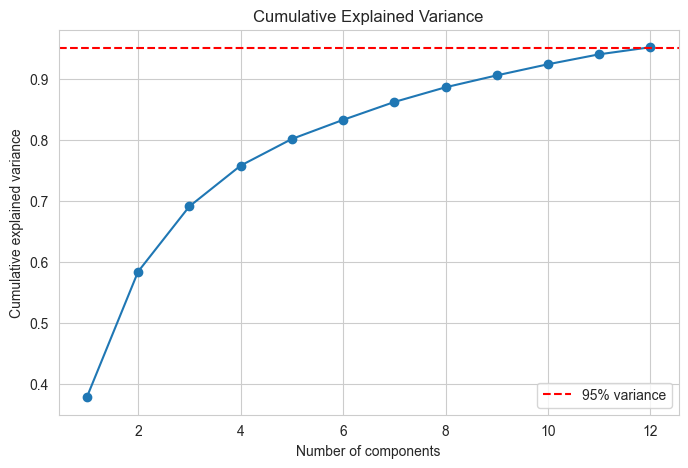

Top features by the first principal component:
maxtemp_times_temparature    0.091985
maxtemp_times_mintemp        0.091872
temparature_times_mintemp    0.091377
maxtemp_plus_temparature     0.091335
maxtemp_div_pressure         0.091245
maxtemp_plus_mintemp         0.091119
maxtemp                      0.091097
pressure_times_maxtemp       0.090920
temparature_div_pressure     0.090913
temparature                  0.090781
dtype: float64

Weighted feature importance across all components:
maxtemp_minus_sunshine        0.053253
sunshine_minus_maxtemp        0.053253
humidity_plus_windspeed       0.053194
mintemp_times_humidity        0.052472
humidity_minus_dewpoint       0.052462
dewpoint_minus_humidity       0.052462
dewpoint_times_humidity       0.052416
maxtemp_plus_humidity         0.052380
temparature_times_humidity    0.052359
maxtemp_times_humidity        0.052354
dtype: float64

Selected features (importance > 0.02):
['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',

In [35]:
X=df_comb
# 1. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Fit PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Print PCA information
print("Number of components selected:", pca.n_components_)
print("Explained variance ratio for each component:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

# 3. Plot cumulative explained variance (scree plot)
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.legend()
plt.title("Cumulative Explained Variance")
plt.show()

# 4. Evaluate the importance of original features based on loadings
loadings = pca.components_.T  

# Method 1: Feature importance based on the first principal component
feature_importance_pc1 = pd.Series(np.abs(loadings[:, 0]), index=X.columns)
print("Top features by the first principal component:")
print(feature_importance_pc1.sort_values(ascending=False).head(10))

# Method 2: Weighted importance combining all components, weighted by explained variance
weighted_importance = np.dot(np.abs(loadings), pca.explained_variance_ratio_)
feature_importance_weighted = pd.Series(weighted_importance, index=X.columns)
print("\nWeighted feature importance across all components:")
print(feature_importance_weighted.sort_values(ascending=False).head(10))


threshold = 0.02  
selected_features = feature_importance_weighted[feature_importance_weighted > threshold].index.tolist()
print("\nSelected features (importance > {}):".format(threshold))
print(selected_features)

**From RandomForest (threshold = 0.02)**
dewpoint_plus_cloud
temparature_plus_cloud
maxtemp_plus_cloud
cloud_div_pressure 
cloud_minus_sunshine     
cloud_minus_pressure     
humidity_times_cloud      
pressure_minus_cloud

**Conclusions from PCA**
- The PCA selected 12 components that together explain about 95% of the total variance
- I would be looking mostly at weighted feature importance, so we could benefit from having columns like: maxtemp_minus_sunshine, sunshine_minus_maxtemp, humidity_plus_windspeed, mintemp_times_humidity

RandomForest and PCA selected totally different columns.